**Note:** This notebook expects representative shorelines to already be computed by `session_rep_and_curveboxplot.ipynb`. If SciPy isn't installed, linear interpolation falls back to NumPy. Update `water_csv` path if your water-level file is in a different location.


# Build 3D Beach Surface from Representative Shorelines

This notebook builds a 3D beach surface by combining representative shorelines from multiple sessions with water level data:

**Workflow:**
1. Reads `rep_shoreline_world.csv` from each session folder (pre-computed by `session_rep_and_curveboxplot.ipynb`)
2. Parses timestamps from folder names (supports UTC format like `walton_lighthouse-2024-01-11-180046Z` and local time format like `surfline_trevone_20260217_0744`)
3. Interpolates water level data (Newlyn tide gauge in feet → meters) to match session timestamps
4. Assigns tide elevation (Z) to each representative shoreline based on its timestamp
5. Builds a triangulated 3D mesh surface spanning time and space
6. Exports as PLY/OBJ formats for visualization in 3D software
7. Generates diagnostic plots (plan-view, tide vs time, 3D surface preview)

**Inputs:**
- `trevone_rec_averaged/`: Folder containing session subfolders with representative shorelines
- `waterlevel/newlyn_coops_format.csv`: Newlyn tide gauge data (converted to CO-OPS format)
- `baseline_warped.csv`: Baseline for enforcing shoreline orientation

**Outputs:**
- `rep_shoreline_3d.csv`: Per-session shoreline with X, Y, Z coordinates
- `all_averaged_3d.csv`: Combined dataset of all sessions
- `beach_surface.ply` & `beach_surface.obj`: 3D mesh files


In [ ]:
# 1) Set up imports, paths, and parameters
import os, re, glob, json, math
from pathlib import Path
from datetime import datetime, timezone, timedelta
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, needed for 3D projection

try:
    from scipy.interpolate import interp1d
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Root directory containing baseline and session subfolders with representative shorelines
root_dir = Path(r"./csv/trevone_smooth_averaged")
water_csv = Path("./waterlevel/newlyn_coops_format.csv")

# Baseline for orientationshare_data/paper/output2.png
baseline_csv = Path(r"./csv/trevone_smooth/baseline/baseline_warped.csv")

# Output locations
out_combined_csv = Path("./csv/3d/trevone_all_averaged_3d.csv")
ply_path = Path("./csv/3d/trevone_beach_surface.ply")
obj_path = Path("./csv/3d/trevone_beach_surface.obj")

# Parameters
N = 400  # Number of points per shoreline (should match session_rep_and_curveboxplot)
FEET_TO_M = 0.3048
FILL_EXTRAPOLATE = True

# Timezone offset for local time (UK is UTC+0 in winter, UTC+1 in summer)
# For Trevone in February 2026, use UTC+0 (GMT)
LOCAL_TZ_OFFSET_HOURS = 0

# Manual shoreline removal (index-based) - adjust as needed
MANUAL_DROP_INDICES_1BASED = []
MANUAL_DROP_VERBOSE = True

# Helper: simple logger
def log(*args):
    print("[build]", *args)

# Helper: case-insensitive column getter with fallbacks
def get_col(df: pd.DataFrame, names: List[str]) -> Optional[str]:
    cols = {c.strip().lower(): c for c in df.columns}
    for name in names:
        key = name.strip().lower()
        if key in cols:
            return cols[key]
    return None

# Read CSV robustly with pandas
def read_csv_robust(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, engine="python")

log("Root:", root_dir)
if not root_dir.exists():
    raise FileNotFoundError(f"Root folder not found: {root_dir}")


[build] Root: csv\seabright_new_smooth_averaged


In [9]:
# 2) Discover session folders and select rep_shoreline_world.csv from each

session_dirs = [p for p in root_dir.iterdir() if p.is_dir()]
session_dirs = sorted(session_dirs)

selected: List[Tuple[Path, Path]] = []  # (session_dir, rep_shoreline_csv)
for d in session_dirs:
    rep_csv = d / "rep_shoreline_world.csv"
    if not rep_csv.exists():
        log("No rep_shoreline_world.csv in", d.name)
        continue
    
    df = read_csv_robust(rep_csv)
    xcol = get_col(df, ["X_warped", "x_warped", "X", "x"])
    ycol = get_col(df, ["Y_warped", "y_warped", "Y", "y"])
    
    if xcol and ycol and df[[xcol, ycol]].dropna().shape[0] >= 2:
        selected.append((d, rep_csv))
    else:
        log("Invalid rep_shoreline_world.csv in", d.name)

log(f"Discovered {len(selected)} session folders with representative shorelines.")
if len(selected) == 0:
    raise RuntimeError("No valid representative shorelines found. Check folder structure.")


[build] Discovered 12 session folders with representative shorelines.


In [10]:
# 3) Parse timestamps from session folder names

# Two formats to handle:
# 1) "walton_lighthouse-2024-01-11-180046Z" -> UTC timestamp
# 2) "surfline_trevone_20260217_0744" -> Local time (YYYYMMDD_HHMM)

def parse_timestamp_from_name(name: str) -> Tuple[Optional[datetime], Optional[str]]:
    s = name.lower()
    
    # Pattern 1: site-YYYY-MM-DD-HHMMSSZ (UTC)
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})-(\d{6})z", s)
    if m:
        y, mo, d, hhmmss = m.groups()
        hh, mm, ss = int(hhmmss[:2]), int(hhmmss[2:4]), int(hhmmss[4:6])
        try:
            return datetime(int(y), int(mo), int(d), hh, mm, ss, tzinfo=timezone.utc), "utc"
        except Exception:
            pass
    
    # Pattern 2: name_YYYYMMDD_HHMM (local time)
    m = re.search(r"(\d{8})_(\d{4})", s)
    if m:
        date_str, time_str = m.groups()
        y = int(date_str[:4])
        mo = int(date_str[4:6])
        d = int(date_str[6:8])
        hh = int(time_str[:2])
        mm = int(time_str[2:4])
        try:
            # Create as local time, then convert to UTC
            local_dt = datetime(y, mo, d, hh, mm, 0)
            utc_dt = local_dt - timedelta(hours=LOCAL_TZ_OFFSET_HOURS)
            return utc_dt.replace(tzinfo=timezone.utc), "local"
        except Exception:
            pass
    
    return None, None

clips_info: List[Dict] = []
for d, csv_path in selected:
    ts, pattern = parse_timestamp_from_name(d.name)
    if ts is None:
        log(f"Could not parse timestamp from: {d.name}")
        continue
    
    clips_info.append({
        "dir": d,
        "csv": csv_path,
        "ts": ts,
        "pattern": pattern,
    })

log(f"Parsed {len(clips_info)} timestamps successfully")
if len(clips_info) == 0:
    raise RuntimeError("No timestamps could be parsed from folder names")


[build] Parsed 12 timestamps successfully


In [11]:
# 4) Load NOAA water-level CSV (GMT), choose Verified or Predicted (ft), convert to meters

wl_df_raw = read_csv_robust(water_csv)
cols_norm = {c: c.strip().lower() for c in wl_df_raw.columns}
wl_df = wl_df_raw.rename(columns=cols_norm)

# Find datetime columns in various forms
# Common forms: 'date' + 'time (gmt)' OR 'datetime (gmt)'
if 'date' in wl_df.columns and any(k in wl_df.columns for k in ['time (gmt)', 'time', 'time gmt']):
    tcol = 'time (gmt)' if 'time (gmt)' in wl_df.columns else ('time' if 'time' in wl_df.columns else 'time gmt')
    dt = pd.to_datetime(wl_df['date'].astype(str) + ' ' + wl_df[tcol].astype(str), utc=True, errors='coerce')
elif any(k in wl_df.columns for k in ['datetime (gmt)', 'datetime', 'date time (gmt)']):
    k = 'datetime (gmt)' if 'datetime (gmt)' in wl_df.columns else ('date time (gmt)' if 'date time (gmt)' in wl_df.columns else 'datetime')
    dt = pd.to_datetime(wl_df[k].astype(str), utc=True, errors='coerce')
else:
    raise RuntimeError("Could not find datetime columns in water level CSV.")

wl_df['dt'] = dt

# Choose Verified (ft) else Predicted (ft), accept variants
cand_cols = [
    'verified (ft)', 'verified', 'verified(ft)',
    'water level (verified) (ft)', 'wl verified (ft)',
    'predicted (ft)', 'predicted', 'predicted(ft)'
]
level_col = None
for c in cand_cols:
    c_low = c.strip().lower()
    if c_low in wl_df.columns:
        level_col = c_low
        break
if level_col is None:
    # try to find any column with '(ft)' that looks numeric
    ft_like = [c for c in wl_df.columns if '(ft' in c]
    if ft_like:
        level_col = ft_like[0]
if level_col is None:
    raise RuntimeError("No Verified/Predicted feet column found in water level CSV.")

wl_df['z_ft'] = pd.to_numeric(wl_df[level_col], errors='coerce')
wl_df['z_m'] = wl_df['z_ft'] * FEET_TO_M
wl_df = wl_df.dropna(subset=['dt', 'z_m']).sort_values('dt')
wl_df = wl_df.drop_duplicates(subset=['dt'], keep='last').reset_index(drop=True)

log("Water series length:", len(wl_df), "from", wl_df['dt'].min(), "to", wl_df['dt'].max())

# Convenience arrays for interpolation
wl_times = wl_df['dt'].astype('int64') // 10**9  # seconds since epoch
wl_vals = wl_df['z_m'].values.astype(float)

if SCIPY_AVAILABLE:
    f_wl = interp1d(wl_times.values, wl_vals, kind='linear', fill_value='extrapolate' if FILL_EXTRAPOLATE else np.nan, bounds_error=False)
else:
    def f_wl(ts_sec):
        x = wl_times.values.astype(float)
        y = wl_vals
        ts = np.asarray(ts_sec, dtype=float)
        # np.interp handles ascending x only
        return np.interp(ts, x, y, left=(y[0] if FILL_EXTRAPOLATE else np.nan), right=(y[-1] if FILL_EXTRAPOLATE else np.nan))


[build] Water series length: 240 from 2024-01-11 00:00:00+00:00 to 2024-01-11 23:54:00+00:00


In [12]:
# Fill dates for HHMM-only clips and compute tide at each clip timestamp

# Determine a reasonable base date: choose the date range covering water level series
wl_min = wl_df['dt'].min()
base_date = datetime(wl_min.year, wl_min.month, wl_min.day, tzinfo=timezone.utc)

resolved = []
for info in clips_info:
    ts = info['ts']
    if ts is None:
        log("Could not parse timestamp:", info['dir'].name)
        continue
    if info['pattern'] == 'p3':
        # Replace YYYY-MM-DD with base_date
        ts = datetime(base_date.year, base_date.month, base_date.day, ts.hour, ts.minute, ts.second, tzinfo=timezone.utc)
    info['ts_resolved'] = ts
    # Interpolate tide
    ts_sec = int(ts.timestamp())
    info['tide_m'] = float(f_wl([ts_sec])[0])
    resolved.append(info)

clips_info = sorted(resolved, key=lambda x: x['ts_resolved'])
log("Resolved", len(clips_info), "clips after timestamp assignment.")

# Summary DataFrame
clips_df = pd.DataFrame([{ 'clip': i['dir'].name, 'timestamp': i['ts_resolved'], 'csv': str(i['csv']), 'tide_m': i['tide_m'] } for i in clips_info])
clips_df

[build] Resolved 12 clips after timestamp assignment.


,clip,timestamp,csv,tide_m
0,walton_lighthouse-2024-01-11-180046Z,2024-01-11 18:00:46+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.986195
1,walton_lighthouse-2024-01-11-183046Z,2024-01-11 18:30:46+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.889303
2,walton_lighthouse-2024-01-11-190046Z,2024-01-11 19:00:46+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.740730
3,walton_lighthouse-2024-01-11-193046Z,2024-01-11 19:30:46+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.570296
4,walton_lighthouse-2024-01-11-200046Z,2024-01-11 20:00:46+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.341696
5,walton_lighthouse-2024-01-11-203748Z,2024-01-11 20:37:48+00:00,csv\seabright_new_smooth_averaged\walton_light...,1.035710
6,walton_lighthouse-2024-01-11-210748Z,2024-01-11 21:07:48+00:00,csv\seabright_new_smooth_averaged\walton_light...,0.774802
7,walton_lighthouse-2024-01-11-212748Z,2024-01-11 21:27:48+00:00,csv\seabright_new_smooth_averaged\walton_light...,0.579831
8,walton_lighthouse-2024-01-11-215748Z,2024-01-11 21:57:48+00:00,csv\seabright_new_smooth_averaged\walton_light...,0.322986
9,walton_lighthouse-2024-01-11-223423Z,2024-01-11 22:34:23+00:00,csv\seabright_new_smooth_averaged\walton_light...,0.023343


In [13]:
# 6) Load baseline_warped.csv and compute reference direction

if not baseline_csv.exists():
    log("baseline_warped.csv not found; proceeding without enforcing orientation.")
    baseline_dir = None
else:
    base_df = read_csv_robust(baseline_csv)
    xb = get_col(base_df, ["X_warped","x_warped","X","x"])
    yb = get_col(base_df, ["Y_warped","y_warped","Y","y"])
    
    if xb is None or yb is None:
        log("baseline_warped.csv missing X/Y; proceeding without enforcing orientation.")
        baseline_dir = None
    else:
        base_pts = base_df[[xb,yb]].dropna().to_numpy(float)
        if len(base_pts) >= 2:
            v = base_pts[-1] - base_pts[0]
            L = np.linalg.norm(v)
            if not np.isfinite(L) or L == 0:
                mu = base_pts.mean(axis=0)
                U, S, VT = np.linalg.svd(base_pts - mu, full_matrices=False)
                v = VT[0]
            else:
                v = v / L
            baseline_dir = v / (np.linalg.norm(v) + 1e-12)
            log("Baseline direction:", baseline_dir)
        else:
            baseline_dir = None
            log("baseline_warped.csv has <2 points; orientation not enforced.")


[build] Baseline direction: [ 0.95791774 -0.28704287]


In [14]:
# 7) Read each representative shoreline, resample to N points, assign tide height

per_clip_outputs: List[Dict] = []
for info in clips_info:
    df = read_csv_robust(info['csv'])
    
    # Check for required columns
    xcol = get_col(df, ["X_warped","x_warped","X","x"])
    ycol = get_col(df, ["Y_warped","y_warped","Y","y"])
    ucol = get_col(df, ["u"])
    
    if xcol is None or ycol is None:
        log(f"Skipping (no X/Y): {info['csv']}")
        continue
    
    xy = df[[xcol, ycol]].dropna().astype(float).to_numpy()
    if len(xy) < 2:
        log(f"Skipping (too few points): {info['csv']}")
        continue
    
    # Get u parameter (should already be there from session_rep_and_curveboxplot)
    if ucol and ucol in df.columns:
        u_orig = df[ucol].to_numpy(float)
    else:
        # Fallback: generate u from 0 to 1
        u_orig = np.linspace(0, 1, len(xy))
    
    # Ensure orientation matches baseline direction
    if baseline_dir is not None:
        try:
            proj = (xy - xy[0]) @ baseline_dir
            if proj[-1] < proj[0]:
                xy = xy[::-1]
                u_orig = u_orig[::-1]
        except Exception:
            pass
    
    # RESAMPLE TO EXACTLY N POINTS for consistent mesh construction
    u_new = np.linspace(0, 1, N)
    x_new = np.interp(u_new, u_orig, xy[:,0])
    y_new = np.interp(u_new, u_orig, xy[:,1])
    xy_resampled = np.column_stack([x_new, y_new])
    
    # Get tide height for this timestamp
    ts_sec = int(info['ts'].timestamp())
    tide_m = float(f_wl([ts_sec])[0])
    
    # Create 3D output with resampled points
    z = np.full(N, tide_m, dtype=float)
    out_df = pd.DataFrame({
        'X_warped': xy_resampled[:,0],
        'Y_warped': xy_resampled[:,1],
        'Z_m': z,
        'u': u_new,
        'timestamp': info['ts'],
        'clip_name': info['dir'].name,
    })
    
    out_path = info['dir'] / "rep_shoreline_3d.csv"
    out_df.to_csv(out_path, index=False)
    info['averaged_3d'] = out_path
    per_clip_outputs.append({ 'info': info, 'df': out_df })
    log(f"Wrote: {out_path} (tide: {tide_m:.3f}m, resampled to {N} points)")

# Show index mapping for manual removal (1-based)
if len(per_clip_outputs) > 0:
    log("Shoreline index mapping (1-based):")
    for idx, e in enumerate(per_clip_outputs, start=1):
        name = e['info']['dir'].name
        tide = e['df']['Z_m'].iloc[0]
        log(f"  {idx}: {name} (tide: {tide:.3f}m)")

# Apply manual index-based drops
if MANUAL_DROP_INDICES_1BASED:
    drop_set = set(MANUAL_DROP_INDICES_1BASED)
    kept = []
    removed = []
    for idx, e in enumerate(per_clip_outputs, start=1):
        if idx in drop_set:
            removed.append((idx, e['info']['dir'].name))
        else:
            kept.append(e)
    if MANUAL_DROP_VERBOSE:
        log(f"Manual removal requested for indices: {sorted(drop_set)}")
        if removed:
            log("Removed shorelines:")
            for i,nm in removed:
                log(f"  {i}: {nm}")
        else:
            log("No shoreline matched removal indices.")
    per_clip_outputs = kept
    log(f"Remaining shorelines after manual drop: {len(per_clip_outputs)}")

# Combined CSV
if len(per_clip_outputs) == 0:
    raise RuntimeError("All shorelines were removed. Adjust MANUAL_DROP_INDICES_1BASED.")

combined_df = pd.concat([e['df'] for e in per_clip_outputs], ignore_index=True)
combined_df.to_csv(out_combined_csv, index=False)
log(f"Wrote combined: {out_combined_csv}")
combined_df.head()


[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-180046Z\rep_shoreline_3d.csv (tide: 1.986m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-183046Z\rep_shoreline_3d.csv (tide: 1.889m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-190046Z\rep_shoreline_3d.csv (tide: 1.741m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-193046Z\rep_shoreline_3d.csv (tide: 1.570m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-200046Z\rep_shoreline_3d.csv (tide: 1.342m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-203748Z\rep_shoreline_3d.csv (tide: 1.036m, resampled to 400 points)
[build] Wrote: csv\seabright_new_smooth_averaged\walton_lighthouse-2024-01-11-210748Z\rep_shoreline_3d.csv (tide: 0.77

,X_warped,Y_warped,Z_m,u,timestamp,clip_name
0,-1.358193e+07,4.434052e+06,1.986195,0.000000,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
1,-1.358193e+07,4.434051e+06,1.986195,0.002506,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
2,-1.358193e+07,4.434050e+06,1.986195,0.005013,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
3,-1.358192e+07,4.434049e+06,1.986195,0.007519,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
4,-1.358192e+07,4.434048e+06,1.986195,0.010025,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z


In [15]:
# 9) Build triangulated 3D surface and export PLY/OBJ

# Sort by time to ensure proper surface connectivity
per_clip_outputs = sorted(per_clip_outputs, key=lambda x: x['info']['ts'])

# Stack curves in time order to form vertices grid (T, N_points, 3)
curves = [e['df'][['X_warped','Y_warped','Z_m']].to_numpy(float) for e in per_clip_outputs]
T = len(curves)
if T < 2:
    raise RuntimeError("Need at least 2 time steps to build a surface.")

# Determine N from first curve (all should have same length after resampling)
N_points = len(curves[0])
log(f"Building surface with {T} time steps and {N_points} points per shoreline")

# Verify all curves have same length
for i, c in enumerate(curves):
    if len(c) != N_points:
        log(f"Warning: curve {i} has {len(c)} points instead of {N_points}")

verts = np.stack(curves, axis=0)  # (T, N_points, 3)

# Build faces
faces = []
for t in range(T-1):
    for j in range(N_points-1):
        a = t*N_points + j
        b = (t+1)*N_points + j
        c = (t+1)*N_points + (j+1)
        d = t*N_points + (j+1)
        faces.append((a,b,c))
        faces.append((a,c,d))
faces = np.asarray(faces, dtype=np.int64)

# Flatten vertices
V = verts.reshape(T*N_points, 3)

# Export ASCII PLY
with open(ply_path, 'w') as f:
    f.write("ply\nformat ascii 1.0\n")
    f.write(f"element vertex {V.shape[0]}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write(f"element face {faces.shape[0]}\n")
    f.write("property list uchar int vertex_indices\nend_header\n")
    for x,y,z in V:
        f.write(f"{x} {y} {z}\n")
    for i,j,k in faces:
        f.write(f"3 {i} {j} {k}\n")
log("Wrote:", ply_path)

# Export OBJ (1-based indices)
with open(obj_path, 'w') as f:
    for x,y,z in V:
        f.write(f"v {x} {y} {z}\n")
    for i,j,k in faces:
        f.write(f"f {i+1} {j+1} {k+1}\n")
log("Wrote:", obj_path)


[build] Building surface with 12 time steps and 400 points per shoreline
[build] Wrote: csv\3d\seabright_beach_surface.ply
[build] Wrote: csv\3d\seabright_beach_surface.obj


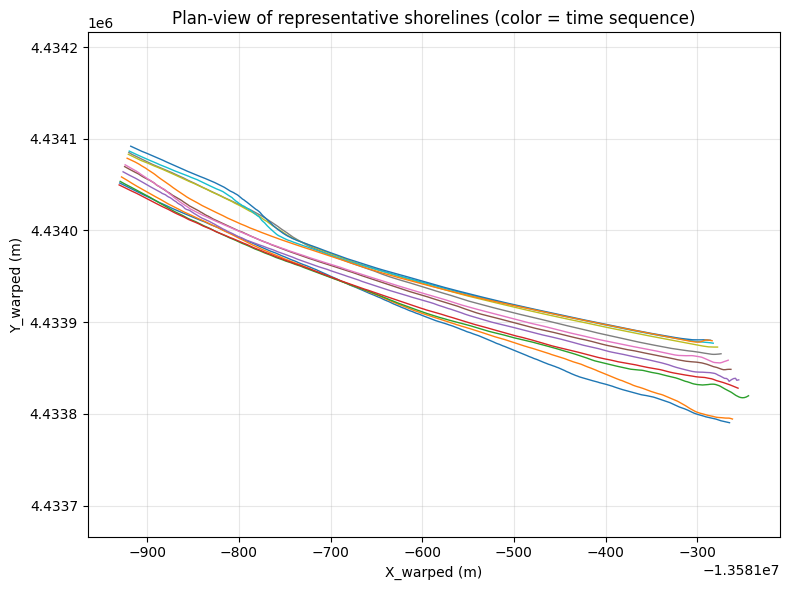

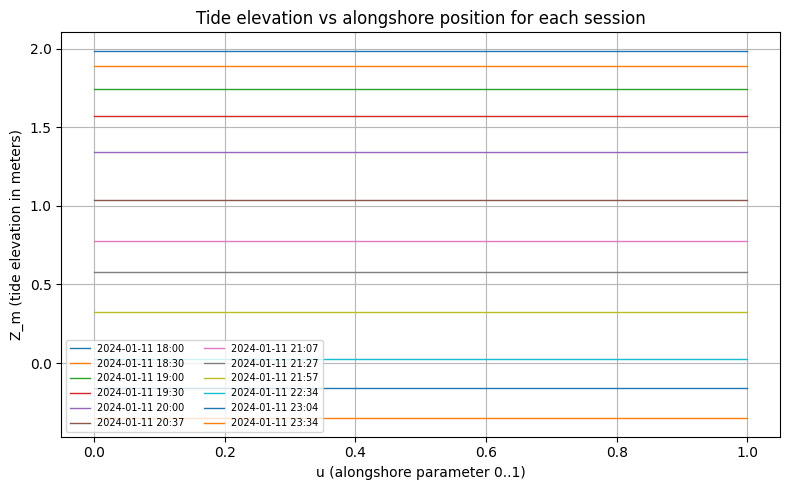

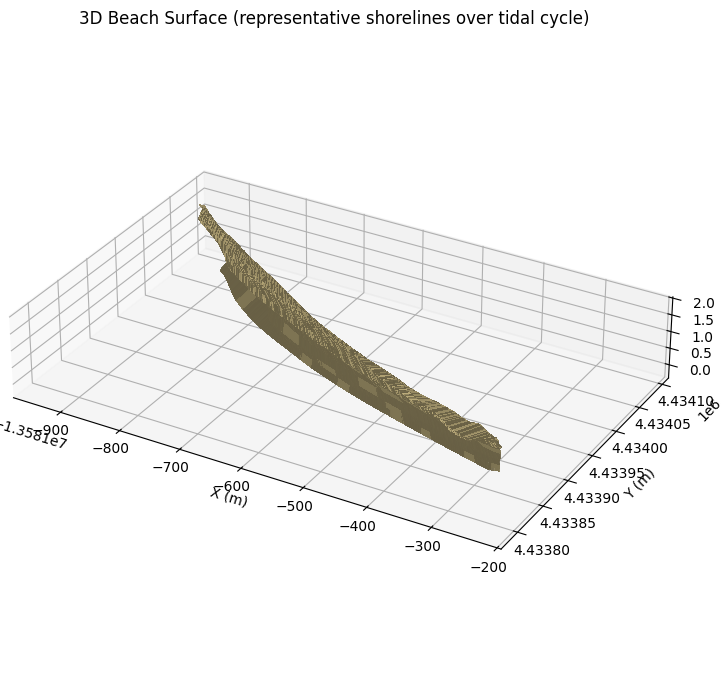

[build] ✓ All plots generated successfully


In [19]:
# 10) Plots to visualize the 3D beach surface

try:
    # Plan-view of all resampled shorelines
    plt.figure(figsize=(8,6))
    for e in per_clip_outputs:
        arr = e['df'][['X_warped','Y_warped']].to_numpy(float)
        tide = e['df']['Z_m'].iloc[0]
        plt.plot(arr[:,0], arr[:,1], linewidth=1, label=f"{e['info']['dir'].name[:20]}.. ({tide:.2f}m)")
    plt.xlabel('X_warped (m)')
    plt.ylabel('Y_warped (m)')
    plt.title('Plan-view of representative shorelines (color = time sequence)')
    plt.axis('equal')
    plt.grid(alpha=0.3)
    if len(per_clip_outputs) <= 10:
        plt.legend(fontsize=7, loc='best')
    plt.tight_layout()
    plt.show()

    # u vs Z_m per session
    plt.figure(figsize=(8,5))
    for e in per_clip_outputs:
        u = e['df']['u'].to_numpy(float)
        z = e['df']['Z_m'].to_numpy(float)
        ts = e['info']['ts']
        plt.plot(u, z, linewidth=1, label=ts.strftime('%Y-%m-%d %H:%M'))
    plt.xlabel('u (alongshore parameter 0..1)')
    plt.ylabel('Z_m (tide elevation in meters)')
    plt.title('Tide elevation vs alongshore position for each session')
    plt.grid(alpha=0.9)
    if len(per_clip_outputs) <= 15:
        plt.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

    # 3D surface preview
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Use subset of faces for faster rendering
    step = max(1, faces.shape[0] // 20000)
    tri_indices = faces[::step]
    
    surf = ax.plot_trisurf(
        V[:,0], V[:,1], V[:,2],
        triangles=tri_indices,
        linewidth=0.0,
        antialiased=False,
        shade=True,
        color='#c2b280',
        edgecolor='none',
        alpha=0.9,
        zorder=8
    )
    
    try:
        fc = surf.get_facecolors()
        if fc.shape[1] == 4:
            fc[:,3] = 0.9
            surf.set_facecolors(fc)
    except Exception:
        pass

    # Set aspect ratio for better visualization
    xr = float(V[:,0].max() - V[:,0].min())
    yr = float(V[:,1].max() - V[:,1].min())
    zr = float(V[:,2].max() - V[:,2].min())
    
    # Adjust these multipliers to control vertical exaggeration
    ax.set_box_aspect((xr, yr * 1.5, zr * 50))
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (tide elevation, m)')
    ax.set_title('3D Beach Surface (representative shorelines over tidal cycle)')
    plt.tight_layout()
    plt.show()
    
    log("✓ All plots generated successfully")
    
except Exception as e:
    log("Plotting skipped due to:", e)
    import traceback
    traceback.print_exc()
